# LG × Tree Size × Sequence Length — Formal Experiment

This is the focused version of the shared Phyloformer 2 pipeline for Karl's
assigned experiment:

- substitution model: **LG**
- tree sizes: **10, 20, 50, 100, 200 taxa**
- sequence lengths: **250, 500, 1000, 2000, 4000 aa**
- fixed clock rate: **1.0**


In [ ]:
# Confirm GPU is connected before proceeding - if this fails, check Runtime > Change runtime type > GPU
!nvidia-smi

Tue Sep 15 14:32:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Clone the Phyloformer repo
!git clone https://github.com/lucanest/Phyloformer.git
%cd Phyloformer

Cloning into 'Phyloformer'...
remote: Enumerating objects: 1051, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 1051 (delta 156), reused 149 (delta 149), pack-reused 871 (from 2)
Receiving objects: 100% (1051/1051), 64.58 MiB | 14.00 MiB/s, done.
Resolving deltas: 100% (558/558), done.
Updating files: 100% (88/88), done.
/content/Phyloformer


In [ ]:
# Clone our TEAM repo too (holds our own docs/notebooks + the Cherry model data files
# that aren't included in the original Phyloformer repo).
# Team repo: https://github.com/ACKarl/EPTI
%cd /content
!git clone https://github.com/ACKarl/EPTI.git team_repo
%cd Phyloformer

/content
Cloning into 'team_repo'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 32 (delta 7), reused 4 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 1.63 MiB | 2.86 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/Phyloformer


In [ ]:
# The original repo's requirements.txt has broken package names (pytorch should be torch)
# and a nonexistent pandas version (3.5.1 doesn't exist) - use this minimal list instead
%%writefile requirements_min.txt
biopython
ete3
dendropy
tqdm
numpy
scipy

Writing requirements_min.txt


In [ ]:
!pip install -r requirements_min.txt -q
# legacy-cgi fixes an ete3 import failure specific to Python 3.13+ (ete3 depends on the removed `cgi` module)
!pip install legacy-cgi -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 62.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 505.4/505.4 kB 43.8 MB/s eta 0:00:00


In [ ]:
# Make binaries executable (Linux/Mac only - skip this line on Windows)
!chmod +x bin/bin_linux/*

In [ ]:
# Two real bugs in the original repo code: the internal seq2pair tensor doesn't reliably move to GPU.
# Both fixes are required - without them, inference crashes with a device-mismatch error.

# Fix 1 - phyloformer/model.py: seq2pair regeneration used the wrong tensor to detect device
!sed -i 's/device = self.seq2pair.device/device = next(self.parameters()).device/' phyloformer/model.py

# Fix 2 - infer_alns.py: seq2pair isn't moved to GPU when the model is, if it's never regenerated
!sed -i '/model = model.to(device)/a\    model.seq2pair = model.seq2pair.to(device)' infer_alns.py

## Imports

Every library used anywhere in this notebook is imported ONCE here. Nothing below
this cell should contain its own `import` statement - Python only needs a library
imported once per session, and repeating it in every function/cell just adds noise.

In [ ]:
import os          # file/folder paths and existence checks
import shutil      # copying and deleting files/folders
import subprocess  # running FastME, IQ-TREE, etc.
import time        # measuring runtime
import glob        # finding saved result files
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from ete3 import Tree


## Shared Functions

Keep and use these functions so that this experiment remains comparable with
the rest of the team.

**Common-tree protocol:** LG and Cherry must use the exact same ground-truth
trees for the `TreeSize_SequenceLength` combination. Always call
`get_or_create_trees()`; do not call `simulate_trees.py` directly.

`get_or_create_trees()` checks the locally cloned team repository, reuses any
matching trees, and creates only missing tree-size groups. Newly generated
files are copied into `/content/team_repo`, but they do **not** become visible
to teammates until you commit and push them with Git.

Always use `run_all_methods_and_combine()` to run Phyloformer, IQ-TREE, and
FastME consistently on the same alignments.


In [ ]:
def clean_dir(path):
    """
    Wipes and recreates a folder. ALWAYS call this before re-running a stage
    (simulate/infer/fastme) on the same output folder - otherwise leftover files
    from a previous run silently corrupt your results (this bit us twice).
    """
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


def clean_dir_no_create(path):
    """
    Use this instead of clean_dir() specifically before calling alisim.py.
    alisim.py insists on creating its own output folder and errors if it
    already exists (even if empty) - so remove it but do NOT recreate it.
    """
    shutil.rmtree(path, ignore_errors=True)


def get_gpu_memory_mb():
    """
    Returns current GPU memory used, in MB, via nvidia-smi. Returns None if no
    GPU is available (e.g. running on CPU). Used to measure Phyloformer's GPU
    memory footprint - call once before and once after inference, and take the
    difference.
    """
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
            capture_output=True, text=True
        )
        return float(result.stdout.strip().split("\n")[0])
    except Exception:
        return None


def compute_metrics(true_trees_dir, predicted_trees_dir, output_prefix):
    """
    Compares predicted trees against true trees.
    Returns a dataframe with RF, normalized RF, weighted RF, and KF distance per tree.
    """
    subprocess.run([
        "./bin/bin_linux/phylocompare", "-t", "-n",
        "-o", output_prefix,
        true_trees_dir, predicted_trees_dir
    ])
    df = pd.read_csv(f"{output_prefix}_topo.csv")
    return df


def run_fastme(input_matrix_dir, output_tree_dir):
    """
    Converts PHYLOFORMER's own neural-network distance matrices into a tree
    using FastME. This is the LAST STEP of the Phyloformer method itself, not
    an independent baseline - see run_fastme_baseline() below for FastME as
    its own separate, independent method.

    IMPORTANT: filters to only .phy files. FastME writes its own companion
    _fastme_stat.txt files into the same input folder - without this filter,
    those get fed back in as if they were real data on the next run, silently
    corrupting results. Always call clean_dir() on both input and output
    folders before a fresh run, on top of this filter, for safety.
    """
    os.makedirs(output_tree_dir, exist_ok=True)
    for file in os.listdir(input_matrix_dir):
        if not file.endswith(".phy"):
            continue
        stem = file.split(".")[0]
        subprocess.run([
            "./bin/bin_linux/fastme",
            "-i", f"{input_matrix_dir}/{file}",
            "-o", f"{output_tree_dir}/{stem}.nwk",
            "--nni", "--spr"
        ])

In [ ]:
def save_trees(trees_dir, tree_params: dict, combo_name, repo_path="/content/team_repo/simulated_data"):
    """
    Saves ground-truth trees to the shared repo, organized by WHICH combination
    study this belongs to, then by the tree-defining parameters (currently just
    clock_rate) - NEVER including substitution model in the folder name.

    Folder layout, e.g.:
      simulated_data/trees/ClockRate_TreeSize/clock_rate=0.5/0_20_tips.nwk
      simulated_data/trees/TreeSize_SequenceLength/clock_rate=1.0/0_50_tips.nwk

    combo_name: a short label for which two parameters this study combines,
    e.g. "ClockRate_TreeSize", "TreeSize_SequenceLength", "ClockRate_SequenceLength".
    Anyone browsing the repo sees immediately which study a tree belongs to,
    before even looking at the parameter values.

    Trees are meant to be shared ACROSS models within the SAME combo: if you're
    doing LG and a teammate is doing Cherry for the same combo/clock-rate/tree-size,
    you both need to simulate sequences on the exact SAME trees for the comparison
    to be meaningful. Naming the folder by model would break that.

    Call this AFTER any clock-rate rescaling - trees_dir should contain the FINAL
    trees that sequences will actually be simulated on, not a pre-rescaling draft.
    """
    tag = "_".join(f"{k}={v}" for k, v in sorted(tree_params.items()))
    dest = os.path.join(repo_path, "trees", combo_name, tag)
    os.makedirs(dest, exist_ok=True)
    n = 0
    for fname in os.listdir(trees_dir):
        if fname.endswith(".nwk") or fname.endswith(".newick"):
            shutil.copy(os.path.join(trees_dir, fname), os.path.join(dest, fname))
            n += 1
    print(f"Saved {n} ground-truth trees to {dest}")


def save_alignments(alignments_dir, params: dict, combo_name, repo_path="/content/team_repo/simulated_data"):
    """
    Saves simulated sequences to the shared repo under "final_sequences",
    organized the SAME way as save_trees() above: by combo_name first, then by
    the full set of parameters used (including model, since sequences SHOULD
    differ by model, unlike trees).

    Folder layout, e.g.:
      simulated_data/final_sequences/ClockRate_TreeSize/clock_rate=0.5_model=LG_seq_length=300/0_20_tips.fasta
      simulated_data/final_sequences/ClockRate_TreeSize/clock_rate=0.5_model=Cherry_seq_length=300/0_20_tips.fasta

    Every combination of parameters (including model) gets its own fully
    labeled folder - repetition across folders is expected and fine (e.g. two
    different combos both testing clock_rate=1.0 will each have their own
    final_sequences copy) since each combo is its own independent study.
    """
    tag = "_".join(f"{k}={v}" for k, v in sorted(params.items()))
    dest = os.path.join(repo_path, "final_sequences", combo_name, tag)
    os.makedirs(dest, exist_ok=True)
    n = 0
    for fname in os.listdir(alignments_dir):
        # alisim.py (LG) outputs .fa, simcherry.sh (Cherry) outputs .fasta - accept both
        if fname.endswith(".fa") or fname.endswith(".fasta"):
            shutil.copy(os.path.join(alignments_dir, fname), os.path.join(dest, fname))
            n += 1
    print(f"Saved {n} sequences to {dest}")


def rescale_tree_branches(input_tree_path, output_tree_path, rate_multiplier):
    """
    Loads a tree and multiplies every branch length by rate_multiplier, then saves it.

    This implements a STRICT molecular clock: one single rate applied uniformly
    across the whole tree. Since sequence divergence = rate x time, rescaling every
    branch length is mathematically equivalent to simulating the same tree evolving
    at a faster (multiplier > 1) or slower (multiplier < 1) substitution rate, while
    keeping tree topology and relative branch proportions unchanged.
    """
    t = Tree(input_tree_path, format=1)
    for node in t.traverse():
        node.dist = node.dist * rate_multiplier
    t.write(outfile=output_tree_path, format=1)


def rescale_all_trees(input_dir, output_dir, rate_multiplier):
    """Applies rescale_tree_branches() to every tree file in a folder."""
    os.makedirs(output_dir, exist_ok=True)
    for fname in os.listdir(input_dir):
        if fname.endswith(".nwk") or fname.endswith(".newick"):
            rescale_tree_branches(
                os.path.join(input_dir, fname),
                os.path.join(output_dir, fname),
                rate_multiplier
            )


def get_or_create_trees(tip_sizes, n_per_size, combo_name, clock_rate=1.0, tree_type="birth-death",
                         local_dir="data/shared_trees",
                         repo_trees_dir="/content/team_repo/simulated_data/trees"):
    """
    THE KEY FUNCTION FOR CROSS-MODEL CONSISTENCY.

    Checks the shared repo's {combo_name}/clock_rate folder PER TIP SIZE (not
    all-or-nothing). Reuses whichever sizes already exist; generates and copies into the local team-repo clone
    ONLY the sizes that are missing. A separate Git commit/push is required to share them. This matters: if a teammate already pushed
    20/50-tip trees and you also need 100-tip trees at the same clock rate,
    this makes sure the 100-tip trees actually get generated - a naive
    all-or-nothing check would silently skip them just because SOME matching
    trees were found.

    combo_name: which combination study this belongs to, e.g. "ClockRate_TreeSize" -
    matches the top-level folder name used by save_trees()/save_alignments().
    Trees are only reused/shared WITHIN the same combo_name - different combo
    studies get their own trees, even if some parameter values overlap, since
    they represent genuinely separate studies.

    ALWAYS use this instead of calling simulate_trees.py directly in a pipeline -
    calling simulate_trees.py yourself creates trees nobody else can reuse, and
    risks two people unknowingly comparing against DIFFERENT trees.
    """
    tag = f"clock_rate={clock_rate}"
    tag_dir = os.path.join(repo_trees_dir, combo_name, tag)
    clean_dir(local_dir)

    existing_by_size = {}
    if os.path.exists(tag_dir):
        for f in os.listdir(tag_dir):
            for t in tip_sizes:
                if f"_{t}_tips" in f:
                    existing_by_size.setdefault(t, []).append(f)

    for t, fnames in existing_by_size.items():
        for f in fnames:
            shutil.copy(os.path.join(tag_dir, f), os.path.join(local_dir, f))
    if existing_by_size:
        print(f"Reused existing trees ('{combo_name}/{tag}') for sizes: {sorted(existing_by_size.keys())}")

    missing_sizes = [t for t in tip_sizes if t not in existing_by_size]

    if missing_sizes:
        print(f"Generating new trees ('{combo_name}/{tag}') for sizes not yet in shared repo: {missing_sizes}")
        raw_dir = local_dir + "_raw"
        clean_dir(raw_dir)
        for t in missing_sizes:
            subprocess.run(["python", "simulate_trees.py", "-n", str(n_per_size), "-t", str(t),
                             "--type", tree_type, "-o", raw_dir])

        if clock_rate != 1.0:
            rescaled_dir = raw_dir + "_rescaled"
            rescale_all_trees(raw_dir, rescaled_dir, clock_rate)
            new_trees_src = rescaled_dir
        else:
            new_trees_src = raw_dir

        for f in os.listdir(new_trees_src):
            shutil.copy(os.path.join(new_trees_src, f), os.path.join(local_dir, f))

        save_trees(new_trees_src, {"clock_rate": clock_rate}, combo_name=combo_name)
    else:
        print(f"All requested tip sizes already available for '{combo_name}/{tag}' - nothing new generated.")

    return local_dir

In [ ]:
def run_iqtree_baseline(alignments_dir, output_dir, model="LG"):
    """
    Runs IQ-TREE directly on each alignment as an INDEPENDENT baseline method
    (maximum likelihood tree search) - NOT just as alisim's alignment simulator,
    which is the only role IQ-TREE played before this function existed.

    As a side effect of a normal run, IQ-TREE also writes a .mldist file - its
    own maximum-likelihood pairwise distance matrix. This is exactly what the
    original Phyloformer paper's "FastME" baseline uses (FastME run on ML
    distances, not on Phyloformer's neural network distances) - see
    run_fastme_baseline() below, which consumes the .mldist files this
    function produces.

    Returns: (mldist_dir, runtime_seconds)
    """
    os.makedirs(output_dir, exist_ok=True)
    mldist_dir = output_dir + "_mldist"
    os.makedirs(mldist_dir, exist_ok=True)

    start = time.time()
    for fname in os.listdir(alignments_dir):
        # alisim.py (used for LG) outputs .fa, simcherry.sh (used for Cherry) outputs
        # .fasta - accept both, since which simulator produced the file depends on
        # which pipeline called this function.
        if not (fname.endswith(".fa") or fname.endswith(".fasta")):
            continue
        stem = fname.split(".")[0]
        aln_path = os.path.join(alignments_dir, fname)
        subprocess.run([
            "bin/bin_linux/iqtree_2.2.0", "-s", aln_path, "-m", model,
            "-nt", "AUTO", "-redo", "-quiet"
        ])

        # IQ-TREE writes its outputs next to the input alignment by default -
        # move the two we actually need, then clean up the rest.
        treefile = aln_path + ".treefile"
        mldist_file = aln_path + ".mldist"
        if os.path.exists(treefile):
            shutil.move(treefile, os.path.join(output_dir, f"{stem}.nwk"))
        if os.path.exists(mldist_file):
            shutil.move(mldist_file, os.path.join(mldist_dir, f"{stem}.mldist"))

        for ext in [".iqtree", ".log", ".bionj", ".ckp.gz", ".model.gz", ".uniqueseq.phy"]:
            side_file = aln_path + ext
            if os.path.exists(side_file):
                os.remove(side_file)
    elapsed = time.time() - start

    print(f"IQ-TREE baseline: processed alignments in {elapsed:.1f}s")
    return mldist_dir, elapsed


def run_fastme_baseline(mldist_dir, output_dir):
    """
    Runs FastME on IQ-TREE's own maximum-likelihood pairwise distances
    (.mldist files) - this is the "FastME" baseline from the original paper,
    a genuinely independent method, distinct from run_fastme() above which
    converts PHYLOFORMER's neural network distance estimates into a tree.
    Same tool (FastME), different input distances.
    """
    os.makedirs(output_dir, exist_ok=True)
    start = time.time()
    for fname in os.listdir(mldist_dir):
        if not fname.endswith(".mldist"):
            continue
        stem = fname.split(".")[0]
        subprocess.run([
            "./bin/bin_linux/fastme",
            "-i", os.path.join(mldist_dir, fname),
            "-o", os.path.join(output_dir, f"{stem}.nwk"),
            "--nni", "--spr"
        ])
    elapsed = time.time() - start
    print(f"FastME (ML-distance) baseline: processed in {elapsed:.1f}s")
    return elapsed


def run_all_methods_and_combine(trees_dir, alignments_dir, pf_checkpoint, work_dir,
                                 iqtree_model="LG"):
    """
    THE STANDARD WAY TO EVALUATE A CONDITION. Runs Phyloformer, IQ-TREE, and
    FastME (on IQ-TREE's ML distances) on the same alignments, compares each
    against the same true trees, and returns ONE combined dataframe tagged by
    a 'method' column, with runtime (and GPU memory, for Phyloformer) recorded
    for every method. Use this instead of calling compute_metrics() on just
    Phyloformer's output - a single number with nothing to compare it against
    doesn't tell you whether Phyloformer is actually doing well.

    iqtree_model: which substitution model IQ-TREE assumes when analysing the
    data. For LG/clock-rate runs, this should match the simulation (LG). For
    CHERRY runs, IQ-TREE has no coevolution model option, so this is left as
    "LG" regardless - meaning the IQ-TREE/FastME baselines for Cherry data are
    running under a KNOWINGLY MISSPECIFIED model. That's a genuine limitation
    worth stating plainly in the report, not a bug to fix here.
    """
    all_dfs = []

    # --- Phyloformer (+ FastME on Phyloformer's own neural-network distances) ---
    pf_matrices_dir = f"{work_dir}/pf_matrices"
    pf_trees_dir = f"{work_dir}/pf_trees"
    clean_dir(pf_matrices_dir)
    clean_dir(pf_trees_dir)

    gpu_before = get_gpu_memory_mb()
    t0 = time.time()
    subprocess.run(["python", "infer_alns.py", "-o", pf_matrices_dir, pf_checkpoint, alignments_dir])
    pf_runtime = time.time() - t0
    gpu_after = get_gpu_memory_mb()
    gpu_used_mb = (gpu_after - gpu_before) if (gpu_before is not None and gpu_after is not None) else None

    run_fastme(pf_matrices_dir, pf_trees_dir)
    df_pf = compute_metrics(trees_dir, pf_trees_dir, f"{work_dir}/verify_pf")
    df_pf["method"] = "Phyloformer"
    df_pf["runtime_seconds"] = pf_runtime
    df_pf["gpu_memory_mb"] = gpu_used_mb
    all_dfs.append(df_pf)

    # --- IQ-TREE (independent ML baseline) ---
    iqtree_trees_dir = f"{work_dir}/iqtree_trees"
    clean_dir(iqtree_trees_dir)
    mldist_dir, iqtree_runtime = run_iqtree_baseline(alignments_dir, iqtree_trees_dir, model=iqtree_model)
    df_iqtree = compute_metrics(trees_dir, iqtree_trees_dir, f"{work_dir}/verify_iqtree")
    df_iqtree["method"] = "IQ-TREE"
    df_iqtree["runtime_seconds"] = iqtree_runtime
    df_iqtree["gpu_memory_mb"] = None
    all_dfs.append(df_iqtree)

    # --- FastME (independent baseline, using IQ-TREE's ML distances) ---
    fastme_ml_trees_dir = f"{work_dir}/fastme_ml_trees"
    clean_dir(fastme_ml_trees_dir)
    fastme_runtime = run_fastme_baseline(mldist_dir, fastme_ml_trees_dir)
    df_fastme = compute_metrics(trees_dir, fastme_ml_trees_dir, f"{work_dir}/verify_fastme")
    df_fastme["method"] = "FastME"
    df_fastme["runtime_seconds"] = fastme_runtime
    df_fastme["gpu_memory_mb"] = None
    all_dfs.append(df_fastme)

    combined = pd.concat(all_dfs, ignore_index=True)
    return combined

In [ ]:
def save_results(df, params: dict, filename, results_dir="/content/team_repo/results"):
    """
    Saves a metrics dataframe to a named results file in the team repo, tagging
    every row with the parameter values that produced it (model, clock_rate,
    etc.) - the 'method' column from run_all_methods_and_combine() is preserved
    as-is, since it's already part of the dataframe.

    UPSERT behavior: if this file already has rows matching the EXACT SAME
    parameter combination (e.g. you're rerunning clock_rate=0.5 after fixing a
    bug or adding more replicates), those old rows are removed and replaced with
    this run's results - NOT duplicated alongside them. Rows for DIFFERENT
    parameter values are left untouched and simply added.

    IMPORTANT: give `filename` something specific to YOU (e.g. "cherry_results.csv",
    "clockrate_results.csv"). Each team member should use their own file, never
    share one filename between people - if two people push changes to the same
    CSV around the same time, git will likely hit a merge conflict. Separate files
    per person avoids this entirely; compile_all_results() below stitches
    everyone's files together at the end.
    """
    os.makedirs(results_dir, exist_ok=True)
    path = os.path.join(results_dir, filename)

    df = df.copy()
    for k, v in params.items():
        df[k] = v
    df["saved_at"] = pd.Timestamp.now().isoformat()

    if os.path.exists(path):
        existing = pd.read_csv(path)
        mask = pd.Series(True, index=existing.index)
        for k, v in params.items():
            if k in existing.columns:
                mask &= (existing[k] == v)
            else:
                mask &= False
        n_replaced = int(mask.sum())
        existing_kept = existing[~mask]
        if n_replaced > 0:
            print(f"Replacing {n_replaced} old rows matching {params} with {len(df)} new rows.")
        combined = pd.concat([existing_kept, df], ignore_index=True)
    else:
        combined = df

    combined.to_csv(path, index=False)
    print(f"Saved {len(df)} rows for {params} -> {path} (file now has {len(combined)} total rows)")


def compile_all_results(results_dir="/content/team_repo/results"):
    """
    Reads every CSV in results_dir and concatenates them into one combined
    dataframe. Run this at the end (after everyone has pushed their results)
    to pull the whole team's data together for final comparison charts.
    """
    files = glob.glob(os.path.join(results_dir, "*.csv"))
    if not files:
        print("No results files found yet.")
        return pd.DataFrame()

    dfs = [pd.read_csv(f) for f in files]
    combined = pd.concat(dfs, ignore_index=True)
    print(f"Compiled {len(files)} files -> {len(combined)} total rows")
    return combined

In [ ]:
MODEL_COLORS = {"LG": "#2E86AB", "Cherry": "#F2A93B"}
METHOD_STYLES = {"Phyloformer": "-o", "IQ-TREE": "--s", "FastME": ":^"}

def plot_parameter_sweep(df, x_col, y_col="kf_score", group_col="model",
                          title="", ylabel="", save_path=None):
    """
    Standard chart for all parameter sweeps.
    Averages multiple trees per x-value and shows error bars (std dev).
    Do NOT plot raw per-tree values directly - with multiple replicates per
    x-value, that produces a misleading zigzag chart instead of a clean trend.
    """
    plt.figure(figsize=(7, 5))
    for model, group in df.groupby(group_col):
        summary = group.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
        color = MODEL_COLORS.get(model, "#888888")
        plt.errorbar(summary[x_col], summary["mean"], yerr=summary["std"],
                     marker="o", label=model, color=color, capsize=4)
    plt.xlabel(x_col)
    plt.ylabel(ylabel or y_col)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_method_comparison(df, x_col, y_col="kf_score", title="", ylabel="", save_path=None):
    """
    Compares methods (Phyloformer / IQ-TREE / FastME) on the same chart -
    use this to see how Phyloformer stacks up against the two baselines,
    for a single model (filter df to one 'model' value before calling this).
    """
    plt.figure(figsize=(7, 5))
    for method, group in df.groupby("method"):
        summary = group.groupby(x_col)[y_col].agg(["mean", "std"]).reset_index()
        style = METHOD_STYLES.get(method, "-o")
        plt.errorbar(summary[x_col], summary["mean"], yerr=summary["std"],
                     fmt=style, label=method, capsize=4)
    plt.xlabel(x_col)
    plt.ylabel(ylabel or y_col)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_runtime(df, x_col, group_col="method", title="Runtime Comparison", save_path=None):
    """Runtime chart across methods (Phyloformer, IQ-TREE, FastME)."""
    plt.figure(figsize=(7, 5))
    for method, group in df.groupby(group_col):
        summary = group.groupby(x_col)["runtime_seconds"].mean().reset_index()
        plt.plot(summary[x_col], summary["runtime_seconds"], marker="o", label=method)
    plt.xlabel(x_col)
    plt.ylabel("Runtime (seconds)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

## Required Sanity Check

**Run this before anything else.** Confirms the whole toolchain (Phyloformer +
FastME + metrics) works correctly on your machine by reproducing the repo's own
published benchmark. If this doesn't print ~0.333, stop and fix your environment
before proceeding.

In [ ]:
!python infer_alns.py -o data/testdata/pf_matrices models/pf.ckpt data/testdata/msas

os.makedirs("data/testdata/pf_trees", exist_ok=True)
run_fastme("data/testdata/pf_matrices", "data/testdata/pf_trees")

df_check = compute_metrics("data/testdata/trees", "data/testdata/pf_trees", "data/test_verify")
print("KF score (expect ~0.333):", df_check["kf_score"].mean())

100% 20/20 [00:05<00:00,  3.51it/s]
KF score (expect ~0.333): 0.332951239908345


## Team-Wide Fixed Baselines

Every combination study varies TWO parameters and holds the THIRD fixed. Use
these exact values whenever a parameter isn't the one you're varying - this
keeps every combo comparable to every other, since none of them accidentally
differ because of an inconsistent "unrelated" parameter.

| Parameter (when NOT being varied) | Fixed value | Where it's set |
|---|---|---|
| Sequence length | **300** | `SEQ_LENGTH` variable |
| Tree size | **50 tips** | `tip_sizes=[50]` (single value, not a list) |
| Clock rate | **1.0** (unscaled) | `clock_rate=1.0` |

- **ClockRate x TreeSize** combo: vary `tip_sizes` (list) and `RATE_MULTIPLIER`, fix `SEQ_LENGTH = 300`.
- **TreeSize x SequenceLength** combo: vary `tip_sizes` (list) and `SEQ_LENGTH`, fix `clock_rate=1.0`.
- **ClockRate x SequenceLength** combo: vary `RATE_MULTIPLIER` and `SEQ_LENGTH`, fix `tip_sizes=[50]` (single value).

## 1. Confirm the Formal Parameters

The table defines 25 parameter combinations (`5 tree sizes × 5 sequence
lengths`), but it does not define the number of replicate trees.

If `R = N_PER_SIZE`, the experiment needs:

- `5 × R` unique common ground-truth trees;
- `25 × R` LG alignments before any duplicate-sequence failures;
- the same ground-truth trees reused for every sequence length and by the
  teammate running the Cherry model.

Leave `N_PER_SIZE = None` until the group confirms it. If the confirmed
value is 20, this means 100 common trees and up to 500 LG alignments.


In [ ]:
# These values come directly from the assigned task.
COMBO_NAME = "TreeSize_SequenceLength"
MODEL_NAME = "LG"
TIP_SIZES = [10, 20, 50, 100, 200]
SEQUENCE_LENGTHS = [250, 500, 1000, 2000, 4000]
CLOCK_RATE = 1.0
TREE_TYPE = "birth-death"

# REQUIRED EDIT: replace None only after the team confirms the formal
# number of replicate trees per taxa size. The template's 20 was a demo.
N_PER_SIZE = 20

RESULT_FILENAME = "ackarl_lg_treesize_seqlength_results.csv"
LOCAL_TREE_DIR = "data/lg_treesize_seqlength/common_trees"

if not isinstance(N_PER_SIZE, int) or N_PER_SIZE <= 0:
    raise ValueError("N_PER_SIZE must be a positive integer.")

print("Experimental conditions:", len(TIP_SIZES) * len(SEQUENCE_LENGTHS))
print("Unique common trees required:", len(TIP_SIZES) * N_PER_SIZE)
print("Expected LG alignments:", len(TIP_SIZES) * len(SEQUENCE_LENGTHS) * N_PER_SIZE)


Experimental conditions: 25
Unique common trees required: 100
Expected LG alignments: 500


## 2. Load the Common Trees from Google Drive, or Generate Them Once

Google Drive is checked **before** `get_or_create_trees(...)` is called.
If Drive contains the complete expected set (20 trees for every requested
taxa size), the notebook points `trees_dir` directly to that Drive folder
and skips tree generation. A partial Drive set is treated as an error so
that trees are never silently mixed, replaced, or regenerated.


In [ ]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount("/content/drive")

DRIVE_CURRENT_DIR = Path("/content/drive/MyDrive/EPTI")
DRIVE_TREE_DIR = (
    DRIVE_CURRENT_DIR
    / "Phyloformer_Project"
    / "common_trees"
    / COMBO_NAME
    / f"clock_rate={CLOCK_RATE}"
)
SHARED_TREES_DIR = (
    Path("/content/team_repo/simulated_data/trees")
    / COMBO_NAME
    / f"clock_rate={CLOCK_RATE}"
)
EXPECTED_TREE_COUNT = len(TIP_SIZES) * N_PER_SIZE


def matching_tree_files(directory, n_tips):
    directory = Path(directory)
    return sorted(
        list(directory.glob(f"*_{n_tips}_tips.nwk"))
        + list(directory.glob(f"*_{n_tips}_tips.newick"))
    )


drive_tree_files = sorted(
    list(DRIVE_TREE_DIR.glob("*.nwk"))
    + list(DRIVE_TREE_DIR.glob("*.newick"))
)
drive_counts = {
    n_tips: len(matching_tree_files(DRIVE_TREE_DIR, n_tips))
    for n_tips in TIP_SIZES
}
DRIVE_TREES_COMPLETE = (
    len(drive_tree_files) == EXPECTED_TREE_COUNT
    and all(count == N_PER_SIZE for count in drive_counts.values())
)

print("Google Drive tree directory:", DRIVE_TREE_DIR)
print("Google Drive tree counts:", drive_counts)
print("Google Drive total tree files:", len(drive_tree_files))

if drive_tree_files and not DRIVE_TREES_COMPLETE:
    raise RuntimeError(
        "Google Drive contains a partial or unexpected common-tree set. "
        f"Expected {N_PER_SIZE} trees for each taxa size and "
        f"{EXPECTED_TREE_COUNT} total, but found {drive_counts} and "
        f"{len(drive_tree_files)} total. Check the folder manually; "
        "no trees were generated or overwritten."
    )

if DRIVE_TREES_COMPLETE:
    print("Complete common trees found in Google Drive; generation will be skipped.")
else:
    print("No common trees found in Google Drive; generation/repository reuse is allowed.")


Mounted at /content/drive
Google Drive tree directory: /content/drive/MyDrive/EPTI/Phyloformer_Project/common_trees/TreeSize_SequenceLength/clock_rate=1.0
Google Drive tree counts: {10: 20, 20: 20, 50: 20, 100: 20, 200: 20}
Google Drive total tree files: 100
Complete common trees found in Google Drive; generation will be skipped.


In [ ]:
# Google Drive takes priority. get_or_create_trees(...) is called only when
# Drive has no tree files for this experiment.
if DRIVE_TREES_COMPLETE:
    trees_dir = str(DRIVE_TREE_DIR)
    TREE_SOURCE = "Google Drive"
    print("Using common trees directly from:", trees_dir)
else:
    existing_counts = {
        n_tips: len(matching_tree_files(SHARED_TREES_DIR, n_tips))
        for n_tips in TIP_SIZES
    }
    print("Existing team-repository tree counts:", existing_counts)

    mismatched_counts = {
        n_tips: count
        for n_tips, count in existing_counts.items()
        if count not in (0, N_PER_SIZE)
    }
    if mismatched_counts:
        raise RuntimeError(
            f"Shared tree counts do not match N_PER_SIZE={N_PER_SIZE}: "
            f"{mismatched_counts}. Stop and confirm with the team."
        )

    # Run this only when Drive does not already contain the complete set.
    # Do NOT put it inside the sequence-length loop.
    trees_dir = get_or_create_trees(
        tip_sizes=TIP_SIZES,
        n_per_size=N_PER_SIZE,
        combo_name=COMBO_NAME,
        clock_rate=CLOCK_RATE,
        tree_type=TREE_TYPE,
        local_dir=LOCAL_TREE_DIR,
    )
    TREE_SOURCE = "team repository and/or newly generated trees"
    print("Common trees available locally at:", trees_dir)


Using common trees directly from: /content/drive/MyDrive/EPTI/Phyloformer_Project/common_trees/TreeSize_SequenceLength/clock_rate=1.0


In [ ]:
selected_tree_counts = {
    n_tips: len(matching_tree_files(trees_dir, n_tips))
    for n_tips in TIP_SIZES
}

for n_tips, count in selected_tree_counts.items():
    print(f"{n_tips:>3} taxa: {count} trees")
    assert count == N_PER_SIZE, (
        f"Expected {N_PER_SIZE} trees for {n_tips} taxa, found {count}."
    )

assert sum(selected_tree_counts.values()) == EXPECTED_TREE_COUNT
print("Tree source:", TREE_SOURCE)
print("Validated total common trees:", sum(selected_tree_counts.values()))


 10 taxa: 20 trees
 20 taxa: 20 trees
 50 taxa: 20 trees
100 taxa: 20 trees
200 taxa: 20 trees
Tree source: Google Drive
Validated total common trees: 100


In [ ]:
if DRIVE_TREES_COMPLETE:
    print("Drive already has the complete set; generation and backup were skipped.")
else:
    SOURCE_TREE_DIR = Path(trees_dir)
    source_tree_files = sorted(
        list(SOURCE_TREE_DIR.glob("*.nwk"))
        + list(SOURCE_TREE_DIR.glob("*.newick"))
    )

    print("Source tree directory:", SOURCE_TREE_DIR)
    print("Source tree count:", len(source_tree_files))

    assert len(source_tree_files) == EXPECTED_TREE_COUNT, (
        f"Expected {EXPECTED_TREE_COUNT} trees, "
        f"but found {len(source_tree_files)}. Backup stopped."
    )

    # The earlier check guarantees that Drive has no tree files here.
    # Copy individual files so an existing empty folder is also supported.
    DRIVE_TREE_DIR.mkdir(parents=True, exist_ok=True)
    for source_file in source_tree_files:
        shutil.copy2(source_file, DRIVE_TREE_DIR / source_file.name)

    saved_tree_files = sorted(
        list(DRIVE_TREE_DIR.glob("*.nwk"))
        + list(DRIVE_TREE_DIR.glob("*.newick"))
    )
    saved_counts = {
        n_tips: len(matching_tree_files(DRIVE_TREE_DIR, n_tips))
        for n_tips in TIP_SIZES
    }

    assert len(saved_tree_files) == EXPECTED_TREE_COUNT
    assert all(count == N_PER_SIZE for count in saved_counts.values())
    assert {path.name for path in saved_tree_files} == {
        path.name for path in source_tree_files
    }

    print("Trees copied to Google Drive:", DRIVE_TREE_DIR)
    print("Verified saved tree counts:", saved_counts)


Drive already has the complete set; generation and backup were skipped.


### Common-tree sharing behavior

When a complete tree set is already present in Google Drive, this notebook
uses that directory directly and does not generate, copy, or overwrite any
tree. If Drive is empty, the existing team-repository trees are reused where
available, missing trees are generated once, and the validated complete set
is then copied to Drive for future runs and teammates.


In [ ]:
# Read-only check: this does not stage, commit, or push anything.
common_tree_repo_path = (
    "simulated_data/trees/TreeSize_SequenceLength/clock_rate=1.0"
)
subprocess.run(
    ["git", "status", "--short", "--", common_tree_repo_path],
    cwd="/content/team_repo",
    check=False,
)


CompletedProcess(args=['git', 'status', '--short', '--', 'simulated_data/trees/TreeSize_SequenceLength/clock_rate=1.0'], returncode=0)

## 3. Run the LG Experiments

Start with one sequence length. After it finishes and the results are
checked/saved, change `SEQUENCE_LENGTHS_TO_RUN` to the next value and rerun
the following experiment cell. This is safer for a long Colab workload.

To intentionally run the whole grid in one session, set:

`SEQUENCE_LENGTHS_TO_RUN = SEQUENCE_LENGTHS`


In [ ]:
# Recommended: one value at a time, for example [250], then [500], etc.
SEQUENCE_LENGTHS_TO_RUN = [250]

invalid_lengths = sorted(set(SEQUENCE_LENGTHS_TO_RUN) - set(SEQUENCE_LENGTHS))
if invalid_lengths:
    raise ValueError(f"Unassigned sequence lengths requested: {invalid_lengths}")
if not SEQUENCE_LENGTHS_TO_RUN:
    raise ValueError("Choose at least one sequence length to run.")

print("This run will process:", SEQUENCE_LENGTHS_TO_RUN)


This run will process: [250]


In [ ]:
completed_this_run = []

for seq_length in SEQUENCE_LENGTHS_TO_RUN:
    print("\n" + "=" * 72)
    print(f"LG experiment: sequence length = {seq_length} aa")
    print("=" * 72)

    work_dir = f"data/lg_treesize_seqlength/seq_length_{seq_length}"
    alignments_dir = f"{work_dir}/alignments"

    # AliSim requires its output directory not to exist beforehand.
    clean_dir_no_create(alignments_dir)

    subprocess.run(
        [
            "python", "alisim.py", trees_dir,
            "-o", alignments_dir,
            "-l", str(seq_length),
            "-g", "GC",
            "-s", "LG",
            "-i", "bin/bin_linux/iqtree_2.2.0",
            "-p", "2",
            "--max-attempts", "100",
        ],
        check=True,
    )

    # AliSim may reject an alignment when duplicate sequences occur.
    alignment_counts = {
        n_tips: len(list(Path(alignments_dir).glob(f"*_{n_tips}_tips.fa")))
        + len(list(Path(alignments_dir).glob(f"*_{n_tips}_tips.fasta")))
        for n_tips in TIP_SIZES
    }
    print("Successful alignment counts:", alignment_counts)

    if sum(alignment_counts.values()) == 0:
        raise RuntimeError(f"AliSim produced no alignments for {seq_length} aa.")

    short_groups = {
        n_tips: count
        for n_tips, count in alignment_counts.items()
        if count != N_PER_SIZE
    }
    if short_groups:
        print(
            "WARNING: Some groups have fewer successful alignments than requested:",
            short_groups,
        )

    df_run = run_all_methods_and_combine(
        trees_dir=trees_dir,
        alignments_dir=alignments_dir,
        pf_checkpoint="models/pf.ckpt",
        work_dir=work_dir,
        iqtree_model="LG",
    )

    # Record requested and actually successful replicate counts explicitly.
    df_run["requested_trees_per_tip_size"] = N_PER_SIZE
    df_run["successful_alignments_for_tip_size"] = (
        df_run["n_tips"].map(alignment_counts)
    )

    params = {
        "combo_name": COMBO_NAME,
        "model": MODEL_NAME,
        "clock_rate": CLOCK_RATE,
        "seq_length": seq_length,
        "tree_type": TREE_TYPE,
        "n_per_size": N_PER_SIZE,
    }

    save_alignments(
        alignments_dir=alignments_dir,
        combo_name=COMBO_NAME,
        params={
            "model": MODEL_NAME,
            "clock_rate": CLOCK_RATE,
            "seq_length": seq_length,
        },
    )
    save_results(df_run, params=params, filename=RESULT_FILENAME)

    print(
        df_run.groupby(["method", "n_tips"])[
            ["kf_score", "norm_rf"]
        ].agg(["mean", "std", "count"])
    )
    completed_this_run.append(seq_length)

print("\nCompleted and saved in this run:", completed_this_run)



LG experiment: sequence length = 250 aa
Successful alignment counts: {10: 20, 20: 19, 50: 16, 100: 12, 200: 5}
IQ-TREE baseline: processed alignments in 2852.5s
FastME (ML-distance) baseline: processed in 1.3s
Saved 72 sequences to /content/team_repo/simulated_data/final_sequences/TreeSize_SequenceLength/clock_rate=1.0_model=LG_seq_length=250
Saved 157 rows for {'combo_name': 'TreeSize_SequenceLength', 'model': 'LG', 'clock_rate': 1.0, 'seq_length': 250, 'tree_type': 'birth-death', 'n_per_size': 20} -> /content/team_repo/results/ackarl_lg_treesize_seqlength_results.csv (file now has 157 total rows)
                    kf_score                   norm_rf                
                        mean       std count      mean       std count
method      n_tips                                                    
FastME      10      1.114762  1.463834    20  0.064286  0.098048    20
            20      1.159392  1.145109    19  0.126935  0.114774    19
            50      1.142393  1.214576

/tmp/ipykernel_2964/999534494.py:138: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(all_dfs, ignore_index=True)


## 4. Check Completion and Plot Preliminary Results

The saved CSV accumulates results across sequence lengths. The table below
makes missing or reduced replicate counts visible instead of silently
treating an incomplete condition as complete.


In [ ]:
result_path = Path("/content/team_repo/results") / RESULT_FILENAME
if not result_path.exists():
    raise FileNotFoundError(f"No saved result file found at {result_path}")

df_saved = pd.read_csv(result_path)
task_results = df_saved[
    (df_saved["combo_name"] == COMBO_NAME)
    & (df_saved["model"] == MODEL_NAME)
    & (df_saved["clock_rate"] == CLOCK_RATE)
].copy()

completion_table = (
    task_results.groupby(["seq_length", "n_tips", "method"])
    .size()
    .rename("result_rows")
    .reset_index()
    .sort_values(["seq_length", "n_tips", "method"])
)
display(completion_table)

finished_lengths = sorted(task_results["seq_length"].unique().tolist())
missing_lengths = sorted(set(SEQUENCE_LENGTHS) - set(finished_lengths))
print("Finished sequence lengths:", finished_lengths)
print("Still missing:", missing_lengths if missing_lengths else "None")


,seq_length,n_tips,method,result_rows
0,250,10,FastME,20
1,250,10,IQ-TREE,20
2,250,10,Phyloformer,5
3,250,20,FastME,19
4,250,20,IQ-TREE,19
5,250,20,Phyloformer,3
6,250,50,FastME,16
7,250,50,IQ-TREE,16
8,250,50,Phyloformer,3
9,250,100,FastME,12


Finished sequence lengths: [250]
Still missing: [500, 1000, 2000, 4000]


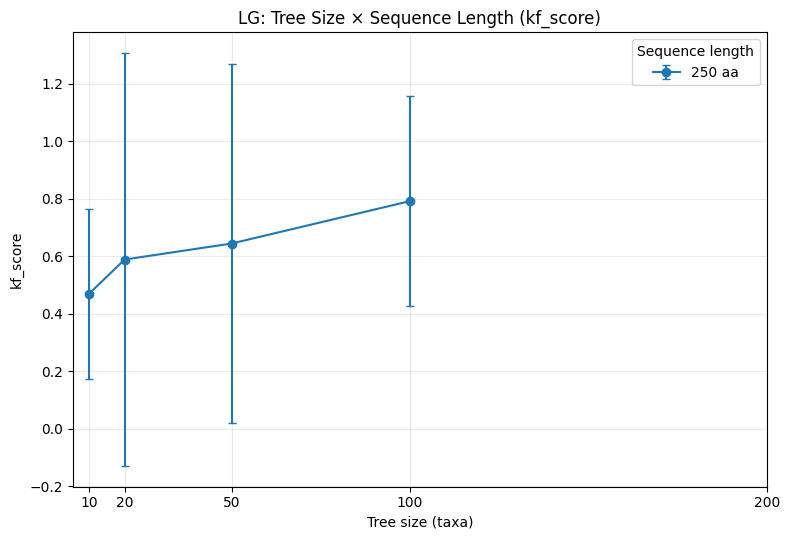

In [ ]:
# Change to "norm_rf" if normalized RF is the report's selected metric.
METRIC_TO_PLOT = "kf_score"

pf_results = task_results[task_results["method"] == "Phyloformer"]
plt.figure(figsize=(8, 5.5))

for seq_length, group in pf_results.groupby("seq_length"):
    summary = group.groupby("n_tips")[METRIC_TO_PLOT].agg(["mean", "std"])
    plt.errorbar(
        summary.index,
        summary["mean"],
        yerr=summary["std"],
        marker="o",
        capsize=3,
        label=f"{int(seq_length)} aa",
    )

plt.xlabel("Tree size (taxa)")
plt.ylabel(METRIC_TO_PLOT)
plt.title(f"LG: Tree Size × Sequence Length ({METRIC_TO_PLOT})")
plt.xticks(TIP_SIZES)
plt.legend(title="Sequence length")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 5. Safe Git Handoff

First inspect the status. Stage only this task's paths—not all of
`simulated_data/` and `results/`—so old demo outputs cannot be pushed by
accident.

Relevant paths are:

- `simulated_data/trees/TreeSize_SequenceLength/clock_rate=1.0/`
- `simulated_data/final_sequences/TreeSize_SequenceLength/`
- `results/ackarl_lg_treesize_seqlength_results.csv`

Commit and push only after checking the counts and filenames. Use a GitHub
token that has write access to `ACKarl/EPTI`; do not type the token into a
notebook cell or save it in notebook output.


In [ ]:
# Read-only final check. This cell cannot commit or push accidentally.
subprocess.run(
    ["git", "status", "--short"],
    cwd="/content/team_repo",
    check=False,
)

print("\nWhen the status is correct, stage only:")
print("git add simulated_data/trees/TreeSize_SequenceLength/clock_rate=1.0/")
print("git add simulated_data/final_sequences/TreeSize_SequenceLength/")
print(f"git add results/{RESULT_FILENAME}")



When the status is correct, stage only:
git add simulated_data/trees/TreeSize_SequenceLength/clock_rate=1.0/
git add simulated_data/final_sequences/TreeSize_SequenceLength/
git add results/ackarl_lg_treesize_seqlength_results.csv
